In [1]:
import pandas as pd

print("Loading data...")
df = pd.read_csv('online_retail.csv', encoding='unicode_escape')

# --- DATA CLEANING PHASE ---

# 1. Drop Missing Customer IDs using the exact name from your list
df = df.dropna(subset=['Customer ID'])

# 2. Remove Canceled Orders & Returns
df = df[df['Quantity'] > 0]

# 3. Calculate Total Monetary Value (Quantity * Price)
df['TotalSales'] = df['Quantity'] * df['Price']

# 4. Format the Dates properly
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

print(f"Cleaned Data Shape: {df.shape}")

Loading data...
Cleaned Data Shape: (805620, 9)


In [2]:
!pip install lifetimes


[notice] A new release of pip is available: 25.1.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
# First time? Run: !pip install lifetimes
import lifetimes

print("Calculating RFM matrix...")

# Hum dataset ki last transaction date ko 'today' maan kar chalenge
current_date = df['InvoiceDate'].max()

# Transaction logs ko RFM format mein convert karna
rfm_data = lifetimes.utils.summary_data_from_transaction_data(
    df,
    customer_id_col='Customer ID',
    datetime_col='InvoiceDate',
    monetary_value_col='TotalSales',
    observation_period_end=current_date
)

display(rfm_data.head())

Calculating RFM matrix...


,frequency,recency,T,monetary_value
Customer ID,,,,
12346.0,7.0,400.0,725.0,11066.637143
12347.0,7.0,402.0,404.0,717.398571
12348.0,4.0,363.0,438.0,449.310000
12349.0,3.0,571.0,589.0,1120.056667
12350.0,0.0,0.0,310.0,0.000000


Training the BG/NBD Model... Please wait.
Model Training Complete! 🚀


C:\Users\Harsh\AppData\Local\Programs\Python\Python313\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


,frequency,recency,probability_alive,predicted_purchases_90_days
Customer ID,,,,
14911.0,254.0,737.0,0.999751,28.580212
12748.0,202.0,735.0,0.999772,22.829960
15311.0,195.0,738.0,0.999764,21.958687
17841.0,192.0,736.0,0.999694,21.647487
14606.0,180.0,735.0,0.999679,20.324139
13089.0,131.0,735.0,0.999510,14.790314
14527.0,120.0,735.0,0.999480,13.554081
14156.0,120.0,729.0,0.998495,13.523836
12971.0,98.0,721.0,0.999313,11.263552


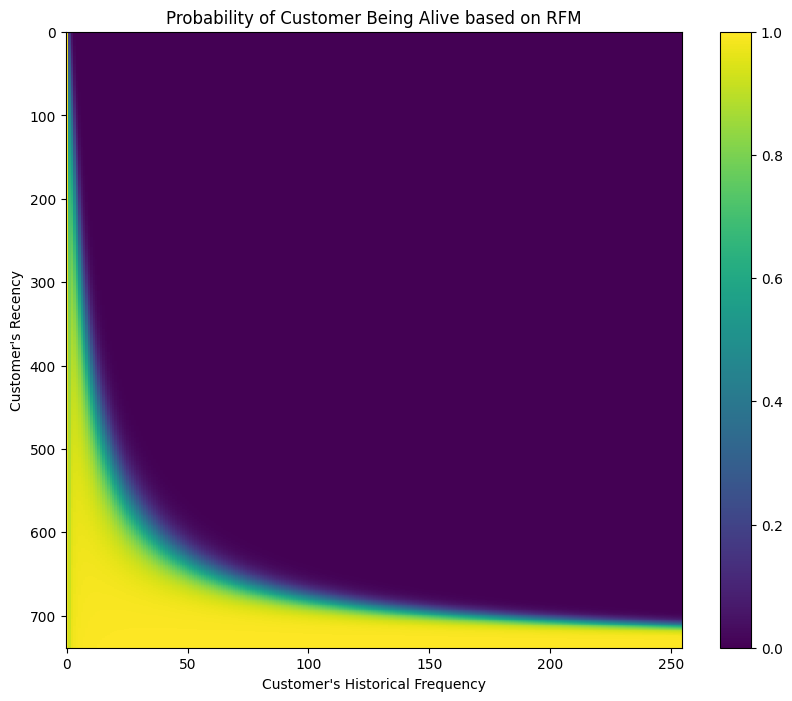

In [4]:
from lifetimes import BetaGeoFitter
import matplotlib.pyplot as plt
from lifetimes.plotting import plot_probability_alive_matrix

print("Training the BG/NBD Model... Please wait.")

# Penalizer thoda sa add karte hain taaki model overfit na ho
bgf = BetaGeoFitter(penalizer_coef=0.01)

# Fitting the model using our RFM data
bgf.fit(rfm_data['frequency'], rfm_data['recency'], rfm_data['T'])

print("Model Training Complete! 🚀")

# 1. Probability that the customer is currently "Alive" (Not Churned)
rfm_data['probability_alive'] = bgf.conditional_probability_alive(
    rfm_data['frequency'], rfm_data['recency'], rfm_data['T']
)

# 2. Predict future purchases for the next 90 days (approx 1 quarter)
t_days = 90
rfm_data['predicted_purchases_90_days'] = bgf.conditional_expected_number_of_purchases_up_to_time(
    t_days, rfm_data['frequency'], rfm_data['recency'], rfm_data['T']
)

# Sort customers to see our most valuable future buyers
top_customers = rfm_data.sort_values(by='predicted_purchases_90_days', ascending=False)
display(top_customers[['frequency', 'recency', 'probability_alive', 'predicted_purchases_90_days']].head(10))

# --- PORTFOLIO VISUALIZATION ---
# Let's plot the "Probability Alive Matrix" to make it look highly professional
plt.figure(figsize=(10, 8))
plot_probability_alive_matrix(bgf)
plt.title("Probability of Customer Being Alive based on RFM")
plt.show()

In [5]:
from lifetimes import GammaGammaFitter

print("Calculating Gamma-Gamma Model...")

# Rule: Gamma-Gamma sirf unhi par kaam karta hai jinhone at least 1 repeat purchase ki ho
returning_customers = rfm_data[rfm_data['frequency'] > 0]

# Pehle correlation check karte hain (should be close to 0)
correlation = returning_customers[['frequency', 'monetary_value']].corr().iloc[0,1]
print(f"Frequency & Monetary Correlation: {correlation:.3f}")
# Agar yeh 0.1 ya 0.2 ke aas-paas hai, toh we are good to go!

# Fit the Gamma-Gamma Model
ggf = GammaGammaFitter(penalizer_coef=0)
ggf.fit(returning_customers['frequency'], returning_customers['monetary_value'])

# Predict Expected Average Order Value
rfm_data['expected_avg_sales'] = ggf.conditional_expected_average_profit(
    rfm_data['frequency'],
    rfm_data['monetary_value']
)

# Calculate Customer Lifetime Value (CLV) for the next 3 months
# Note: BG/NBD model bhi paas karna padta hai taaki probability of alive consider ho
rfm_data['CLV_3_Months'] = ggf.customer_lifetime_value(
    bgf, # Tumhara pichla BG/NBD model
    rfm_data['frequency'],
    rfm_data['recency'],
    rfm_data['T'],
    rfm_data['monetary_value'],
    time=3, # 3 Months
    discount_rate=0.01 # Monthly discount rate for finance mapping
)

print("\nTop 10 Customers by CLV:")
display(rfm_data.sort_values(by='CLV_3_Months', ascending=False)[['frequency', 'expected_avg_sales', 'CLV_3_Months']].head(10))

# --- EXPORT FOR BI DASHBOARD ---
# Is final dataset ko hum Power BI / Tableau ke liye save karenge
rfm_data.to_csv('final_clv_predictions.csv')
print("\nSuccess! Dataset exported as 'final_clv_predictions.csv'")

Calculating Gamma-Gamma Model...
Frequency & Monetary Correlation: 0.023

Top 10 Customers by CLV:


C:\Users\Harsh\AppData\Local\Programs\Python\Python313\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


,frequency,expected_avg_sales,CLV_3_Months
Customer ID,,,
18102.0,66.0,9034.693534,66222.692475
14646.0,90.0,5739.556493,57297.983427
16446.0,1.0,77223.526606,38747.710743
17450.0,30.0,6676.381814,35895.322341
14156.0,120.0,2585.787390,34282.227003
14096.0,16.0,3818.357285,33936.672780
14911.0,254.0,1158.854127,32469.121031
13694.0,82.0,2337.353026,21323.631008
12415.0,22.0,6150.546624,20693.713890



Success! Dataset exported as 'final_clv_predictions.csv'


In [6]:
# Yeh command hume data ki statistics dikhayegi
display(rfm_data[['CLV_3_Months', 'frequency']].describe())

,CLV_3_Months,frequency
count,5.503000e+03,5881.000000
mean,4.098323e+02,4.630335
std,1.808950e+03,10.001176
min,3.329564e-07,0.000000
25%,5.526019e+01,0.000000
50%,1.367722e+02,2.000000
75%,3.720737e+02,5.000000
max,6.622269e+04,254.000000
